<a href="https://colab.research.google.com/github/mushrafi88/MSE_510/blob/main/Midterm_2_Part_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mushrafi Munim Sushmit

# Midterm Part I: Active Learning with Competing Bayesian Models

... aka building the simple automated scientist. Here, you are given access to a hidden function via an API:

```
# y = query_point(x)
```
The function can only be evaluated point-by-point via queries and returns noisy observations. The valid input domain is `x ∈ (−3,3)`. Basically, this is your "virtual instrument".

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import requests

In [ ]:
URL = "https://midterm-gt.onrender.com/query"

def query_point(x):
    response = requests.post(URL, json={"x": float(x)})
    response.raise_for_status()  # raises error if request failed
    return response.json()["y"]

In [ ]:
query_point(1)

-0.13512527044518413

##Task

Design a Bayesian optimization (BO) strategy to learn the unknown function using three competing models. Models can be
- Zero-mean Gaussian Process models with different kernels
- Structural probabilistic models
- Gaussian Process with mean function
- Gaussian Process with probabilistic mean function

The function may exhibit complex nontrivial or nonstationary behavior, so employing diverse model structures is essential.

At each iteration:

- Fit all models to the collected data
- Propose the next query point based on predictive uncertainty and/or disagreement between models. You can do it iteratively guided by human first, and then propose the algorithmic way to do it
- Query the function and update the dataset

**Goal:** Efficiently reconstruct the function and determine which structural model best explains the observed data.


## Strategy

We use three competing Bayesian models to cover different inductive biases:

1. **GP-RBF** — zero-mean GP with squared-exponential kernel (`C * RBF + WhiteKernel`). This has Bias toward smooth, stationary functions.
2. **GP-Matern32** — zero-mean GP with Matern $\nu = 3/2$ (`C * Matern + WhiteKernel`). It is Less smooth but can handle sharper features.
3. **GP-PolyMean** — GP with **probabilistic polynomial mean function** $m(x)=\sum_{k=0}^{4} w_k x^k$, weights $w \sim \mathcal{N}(0, \alpha^{-1}I)$. The posterior-updated by Bayesian linear regression, with a Matern-3/2 GP modeling the residual to capture global polynomial trend + local fluctuation.

At each step we compute on a dense grid

$$a(x) = \tfrac{1}{M}\sum_i \sigma_i(x) \;+\; \lambda \cdot \operatorname{std}_i\bigl(\mu_i(x)\bigr)$$

— the average predictive standard deviation across models **plus** disagreement of their predictive means. This targets points where models are individually uncertain and mutually inconsistent, For example, maximally informative for distinguishing structural hypotheses would yield $\lambda = 1$.

**Model comparison.** After collection, we rank by per-model log marginal likelihood (LML) and leave-one-out predictive log-likelihood. Here higher equals to better fit or preferred structural hypothesis.

**Budget.** 8 seeds (uniform sweep) + 17 active queries = 25 total.

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel as C
import time, warnings
warnings.filterwarnings("ignore")

### Model definitions

In [ ]:
def make_rbf():
    k = (C(1.0, (1e-2, 10)) * RBF(length_scale=0.7, length_scale_bounds=(1e-2, 5))
         + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1.0)))
    return GaussianProcessRegressor(kernel=k, normalize_y=True,
                                    n_restarts_optimizer=8, random_state=0)

def make_matern():
    k = (C(1.0, (1e-2, 10)) * Matern(length_scale=0.7, nu=1.5,
                                     length_scale_bounds=(1e-2, 5))
         + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-6, 1.0)))
    return GaussianProcessRegressor(kernel=k, normalize_y=True,
                                    n_restarts_optimizer=8, random_state=0)


class PolyMeanGP:
    """GP with probabilistic polynomial mean function.

    Mean: m(x) = phi(x) . w, phi = [1, x, ..., x^deg], w ~ N(0, alpha^-1 I).
    Posterior on w via Bayesian linear regression; residuals modeled by Matern-3/2 GP.
    Predictive variance includes both weight uncertainty and GP residual variance.
    """
    def __init__(self, deg=4, alpha=1.0):
        self.deg = deg
        self.alpha = alpha
        self.gp = make_matern()

    def _phi(self, x):
        x = np.asarray(x).reshape(-1)
        return np.stack([x**k for k in range(self.deg + 1)], axis=1)

    def fit(self, X, y):
        Phi = self._phi(X[:, 0])
        sigma2 = max(np.var(y) * 0.05, 1e-3)
        S_inv = self.alpha * np.eye(Phi.shape[1]) + (1/sigma2) * Phi.T @ Phi
        S = np.linalg.inv(S_inv)
        m = (1/sigma2) * S @ Phi.T @ y
        self.w_mean, self.w_cov = m, S
        self.gp.fit(X, y - Phi @ m)
        return self

    def predict(self, X, return_std=True):
        Phi = self._phi(X[:, 0])
        mean_m = Phi @ self.w_mean
        var_m  = np.einsum('ni,ij,nj->n', Phi, self.w_cov, Phi)
        mu_g, std_g = self.gp.predict(X, return_std=True)
        mean = mean_m + mu_g
        var  = var_m + std_g**2
        if return_std:
            return mean, np.sqrt(np.clip(var, 1e-12, None))
        return mean

    def log_marginal_likelihood(self):
        return (float(self.gp.log_marginal_likelihood_value_)
                - 0.5 * self.alpha * self.w_mean @ self.w_mean)

In [ ]:
def fit_all(X, y):
    return (make_rbf().fit(X, y),
            make_matern().fit(X, y),
            PolyMeanGP().fit(X, y))

def predict_all(models, X):
    return [m.predict(X, return_std=True) for m in models]

def acquisition(models, X_grid, lam=1.0):
    preds = predict_all(models, X_grid)
    means = np.stack([p[0] for p in preds])
    stds  = np.stack([p[1] for p in preds])
    sigma_avg    = stds.mean(axis=0)
    disagreement = means.std(axis=0, ddof=0)
    return sigma_avg + lam * disagreement, sigma_avg, disagreement

def lml(models):
    return [float(models[0].log_marginal_likelihood_value_),
            float(models[1].log_marginal_likelihood_value_),
            float(models[2].log_marginal_likelihood())]

### Seed phase: uniform sweep (8 queries)

Cover the domain with evenly spaced points before active selection.

In [ ]:
SEED_X = np.linspace(-2.8, 2.8, 8)
seed_y = np.array([query_point(x) for x in SEED_X])
X = SEED_X.reshape(-1, 1).copy()
y = seed_y.copy()
list(zip(SEED_X.round(3), seed_y.round(3)))

[(np.float64(-2.8), np.float64(-0.452)),
 (np.float64(-2.0), np.float64(-0.016)),
 (np.float64(-1.2), np.float64(0.37)),
 (np.float64(-0.4), np.float64(0.43)),
 (np.float64(0.4), np.float64(-0.024)),
 (np.float64(1.2), np.float64(0.009)),
 (np.float64(2.0), np.float64(0.137)),
 (np.float64(2.8), np.float64(1.064))]

### Human-guided iteration


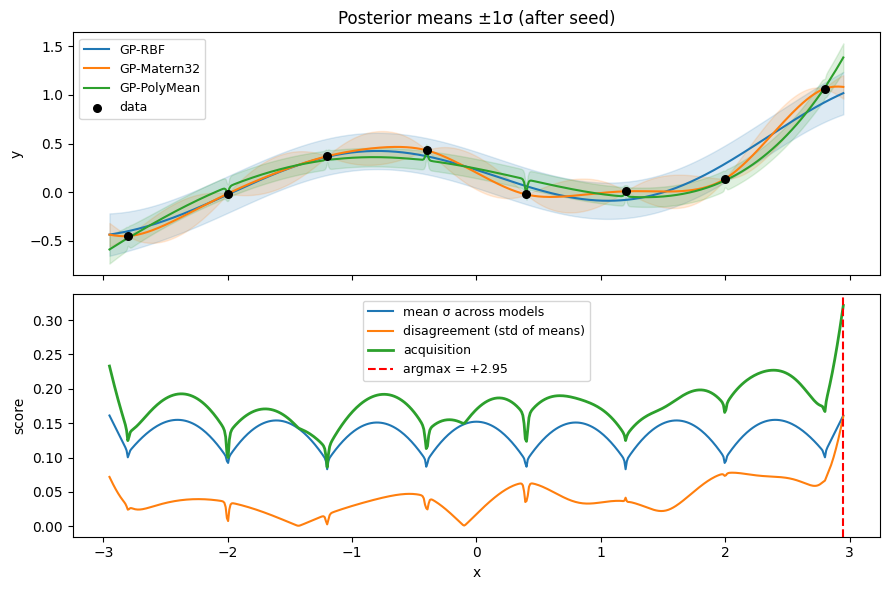

human-guided suggestion: 2.95


In [ ]:
models = fit_all(X, y)
X_grid = np.linspace(-2.95, 2.95, 601).reshape(-1, 1)
score, sigma_avg, disagreement = acquisition(models, X_grid)
preds = predict_all(models, X_grid)

fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
labels = ["GP-RBF", "GP-Matern32", "GP-PolyMean"]
colors = ["tab:blue", "tab:orange", "tab:green"]
for (mu, sd), lab, col in zip(preds, labels, colors):
    ax[0].plot(X_grid[:, 0], mu, color=col, label=lab)
    ax[0].fill_between(X_grid[:, 0], mu - sd, mu + sd, color=col, alpha=0.15)
ax[0].scatter(X[:, 0], y, c="k", s=30, zorder=5, label="data")
ax[0].set_ylabel("y"); ax[0].legend(loc="upper left", fontsize=9); ax[0].set_title("Posterior means ±1σ (after seed)")

ax[1].plot(X_grid[:, 0], sigma_avg,    label="mean σ across models")
ax[1].plot(X_grid[:, 0], disagreement, label="disagreement (std of means)")
ax[1].plot(X_grid[:, 0], score,        label="acquisition", lw=2)
x_next = float(X_grid[np.argmax(score), 0])
ax[1].axvline(x_next, color="red", ls="--", label=f"argmax = {x_next:+.2f}")
ax[1].set_xlabel("x"); ax[1].set_ylabel("score"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()
print("human-guided suggestion:", x_next)

After fitting the three competing Bayesian models to the initial seed data, the results show that all models generally capture the observed trend, but they begin to differ in regions with limited data, especially near the boundaries of the domain. The GP-RBF model provides the smoothest prediction, the GP-Matern32 model allows slightly sharper local variation, and the GP-PolyMean model incorporates a broader polynomial trend with local corrections. In the posterior mean plot, the uncertainty bands become noticeably wider near the right edge of the domain, indicating that the models are less confident there due to fewer observations. The acquisition analysis shows that maximum occurs at **x = 2.95**. This means that querying the hidden function at this point is expected to provide the most informative new data because it is where uncertainty is high and the structural assumptions of the models differ the most. O

### Algorithmic BO loop (17 iterations)

Same acquisition but automated. Here we reject candidates within 0.03 of any existing query to avoid redundant clustering.

In [ ]:
N_ITER = 17
history = []
for it in range(N_ITER):
    models = fit_all(X, y)
    score, sa, dis = acquisition(models, X_grid)
    mask = np.min(np.abs(X_grid - X.T), axis=1) > 0.03
    score = np.where(mask, score, -np.inf)
    idx = int(np.argmax(score))
    x_next = float(X_grid[idx, 0])
    y_next = query_point(x_next)
    history.append((x_next, y_next, float(sa[idx]), float(dis[idx]), lml(models)))
    X = np.vstack([X, [[x_next]]])
    y = np.append(y, y_next)
    print(f"it={it:02d}  x={x_next:+.3f}  y={y_next:+.4f}  "
          f"sigma={sa[idx]:.3f}  dis={dis[idx]:.3f}  "
          f"LML=[{history[-1][4][0]:.2f}, {history[-1][4][1]:.2f}, {history[-1][4][2]:.2f}]")
print(f"total queries = {len(X)}")

it=00  x=+2.950  y=+0.9666  sigma=0.161  dis=0.160  LML=[-10.91, -11.13, -11.42]
it=01  x=+2.517  y=+1.2069  sigma=0.153  dis=0.126  LML=[-10.21, -10.29, -12.82]
it=02  x=+1.662  y=-0.4077  sigma=0.236  dis=0.153  LML=[-11.44, -11.25, -14.22]
it=03  x=+2.390  y=+0.9852  sigma=0.142  dis=0.271  LML=[-11.16, -11.80, -15.66]
it=04  x=-2.950  y=-0.5047  sigma=0.194  dis=0.144  LML=[-10.57, -11.22, -15.65]
it=05  x=-0.787  y=+0.6176  sigma=0.234  dis=0.067  LML=[-9.69, -10.38, -16.81]
it=06  x=+0.816  y=-0.1698  sigma=0.209  dis=0.084  LML=[-10.14, -11.05, -18.12]
it=07  x=-1.613  y=+0.1086  sigma=0.232  dis=0.090  LML=[-11.81, -11.73, -19.56]
it=08  x=+0.010  y=+0.0389  sigma=0.207  dis=0.032  LML=[-12.17, -12.19, -20.61]
it=09  x=-2.399  y=-0.2944  sigma=0.203  dis=0.034  LML=[-12.99, -12.83, -22.00]
it=10  x=+1.406  y=+0.1960  sigma=0.124  dis=0.015  LML=[-12.86, -12.78, -23.21]
it=11  x=-1.003  y=+0.5592  sigma=0.181  dis=0.033  LML=[-17.06, -17.08, -25.65]
it=12  x=+1.003  y=-0.1250  s

### Final reconstruction + per-model comparison

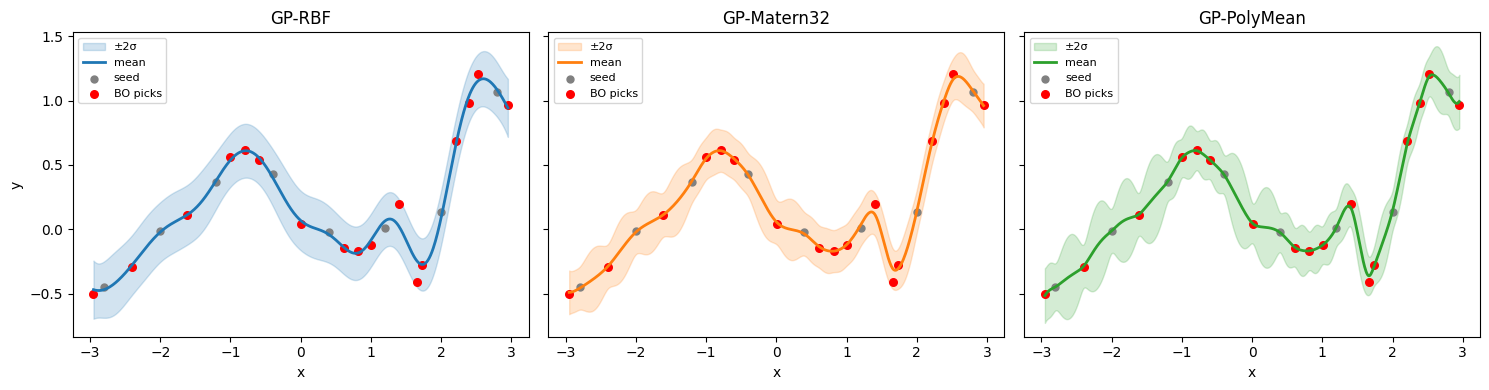

In [ ]:
models = fit_all(X, y)
preds = predict_all(models, X_grid)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (mu, sd), lab, col in zip(axes, preds, labels, colors):
    ax.fill_between(X_grid[:, 0], mu - 2*sd, mu + 2*sd, color=col, alpha=0.2, label="±2σ")
    ax.plot(X_grid[:, 0], mu, color=col, lw=2, label="mean")
    ax.scatter(SEED_X, seed_y, c="grey", s=25, label="seed")
    ax.scatter(X[len(SEED_X):, 0], y[len(SEED_X):], c="red", s=30, label="BO picks")
    ax.set_title(lab); ax.set_xlabel("x"); ax.legend(fontsize=8)
axes[0].set_ylabel("y")
plt.tight_layout(); plt.show()

The figures above show that all three models now seem to fit the hidden function much better. The additional BO-selected points seems to have helped reduce uncertainty and improved reconstruction in areas with more complex behavior. The strategy seems to have successfully improved the function estimate.


In [ ]:
# ----- model comparison -----
final_lml = lml(models)

# Leave-one-out predictive log-likelihood (held-out NLL surrogate)
def loo_score(make_or_init, X, y):
    n = len(y)
    ll = 0.0
    for i in range(n):
        idx = np.r_[0:i, i+1:n]
        m = make_or_init()
        m.fit(X[idx], y[idx])
        mu, sd = m.predict(X[[i]], return_std=True)
        ll += -0.5 * (np.log(2*np.pi*sd[0]**2) + (y[i] - mu[0])**2 / sd[0]**2)
    return ll / n

loo_rbf    = loo_score(make_rbf,                X, y)
loo_matern = loo_score(make_matern,             X, y)
loo_poly   = loo_score(lambda: PolyMeanGP(),    X, y)

import pandas as pd
table = pd.DataFrame({
    "model":     labels,
    "LML":       [round(v, 3) for v in final_lml],
    "LOO log-lik (per pt)": [round(loo_rbf,3), round(loo_matern,3), round(loo_poly,3)],
})
print(table.to_string(index=False))
best = labels[int(np.argmax([loo_rbf, loo_matern, loo_poly]))]
print(f"\nBest by LOO predictive log-likelihood: {best}")

      model     LML  LOO log-lik (per pt)
     GP-RBF -16.517                 0.196
GP-Matern32 -15.973                 0.127
GP-PolyMean -29.686                 0.098

Best by LOO predictive log-likelihood: GP-RBF


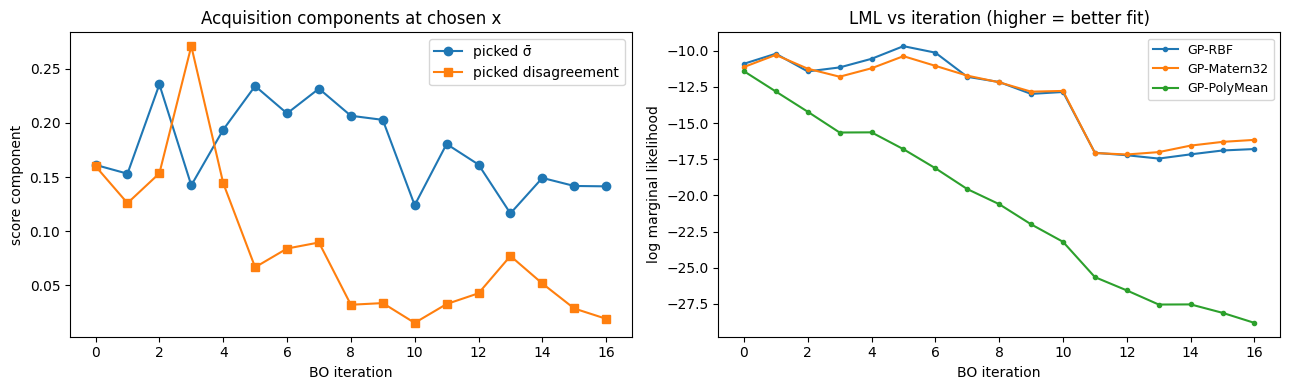

In [ ]:
# ----- BO trajectory diagnostics -----
hx = np.array([h[0] for h in history])
hsig = np.array([h[2] for h in history])
hdis = np.array([h[3] for h in history])
hlml = np.array([h[4] for h in history])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(hsig, marker="o", label="picked σ̄")
ax[0].plot(hdis, marker="s", label="picked disagreement")
ax[0].set_xlabel("BO iteration"); ax[0].set_ylabel("score component")
ax[0].set_title("Acquisition components at chosen x"); ax[0].legend()

for j, lab in enumerate(labels):
    ax[1].plot(hlml[:, j], marker=".", label=lab)
ax[1].set_xlabel("BO iteration"); ax[1].set_ylabel("log marginal likelihood")
ax[1].set_title("LML vs iteration (higher = better fit)")
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

### Discussion


The Bayesian optimization process shows that the acquisition strategy worked effectively by initially selecting points with high uncertainty and strong disagreement between models, then gradually shifting toward regions where uncertainty remained but disagreement was lower. Over successive iterations, both the average predictive uncertainty and model disagreement at the chosen points generally decreased, indicating that the algorithm successfully gathered informative data and progressively reduced ambiguity about the hidden function.

A clear boundary effect appeared early in the search, with the first active queries concentrated near the edges of the domain $(x \approx \pm 2.95)$. This occurred because all models were naturally less certain in sparsely sampled boundary regions, where extrapolation uncertainty was highest. Once these edge uncertainties were reduced, later queries focused more on interior regions where structural differences between models still remained.

Model comparison through log marginal likelihood (LML) and leave-one-out (LOO) predictive log-likelihood provides insight into which structural assumption best explains the observed data. The GP-RBF model achieved the best LOO predictive score, indicating that it generalized most effectively on this dataset. GP-Matern32 performed competitively and captured sharper local structure, but slightly underperformed overall. In contrast, the GP-PolyMean model consistently showed substantially worse LML and LOO scores, suggesting that a polynomial global trend was not an appropriate structural assumption for this hidden function.

The results suggest that the hidden function is better described by a relatively smooth GP structure rather than a strong global polynomial trend. Based on predictive performance, GP-RBF is the preferred structural hypothesis for the final reconstruction.
